In [ ]:
# Importing Libraries

In [1]:
import pandas as pd

In [2]:
import numpy as np


In [3]:

import matplotlib.pyplot as plt

In [4]:
import seaborn as sns


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [6]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Loading Dataset

In [9]:
df=pd.read_csv("/content/drive/MyDrive/House_price_prediction.csv")

In [10]:
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [11]:
df.shape

(148, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              148 non-null    object 
 1   UNDER_CONSTRUCTION     148 non-null    int64  
 2   RERA                   148 non-null    int64  
 3   BHK_NO.                148 non-null    int64  
 4   BHK_OR_RK              148 non-null    object 
 5   SQUARE_FT              148 non-null    float64
 6   READY_TO_MOVE          148 non-null    int64  
 7   RESALE                 148 non-null    int64  
 8   ADDRESS                148 non-null    object 
 9   LONGITUDE              148 non-null    float64
 10  LATITUDE               148 non-null    float64
 11  TARGET(PRICE_IN_LACS)  148 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 14.0+ KB


In [17]:
# Exploratory Data Analysis

In [13]:
# Check Missing Values
df.isnull().sum()

,0
POSTED_BY,0
UNDER_CONSTRUCTION,0
RERA,0
BHK_NO.,0
BHK_OR_RK,0
SQUARE_FT,0
READY_TO_MOVE,0
RESALE,0
ADDRESS,0
LONGITUDE,0


In [14]:
# Descriptive Statistics
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,0.168919,0.331081,2.412162,1598.170747,0.831081,0.952703,21.157821,77.402912,149.375676
std,0.375953,0.472200,0.781844,3317.169108,0.375953,0.212995,6.166271,3.871845,747.999864
min,0.000000,0.000000,1.000000,301.917116,0.000000,0.000000,9.930471,71.392013,11.000000
25%,0.000000,0.000000,2.000000,944.443069,1.000000,1.000000,15.219562,74.830053,38.750000
50%,0.000000,0.000000,2.000000,1150.103660,1.000000,1.000000,21.099728,77.381494,60.000000
75%,0.000000,1.000000,3.000000,1537.140327,1.000000,1.000000,26.955346,77.683457,89.700000
max,1.000000,1.000000,5.000000,40606.195680,1.000000,1.000000,30.740000,88.484911,9110.000000


In [15]:
# Target Variable Distribution

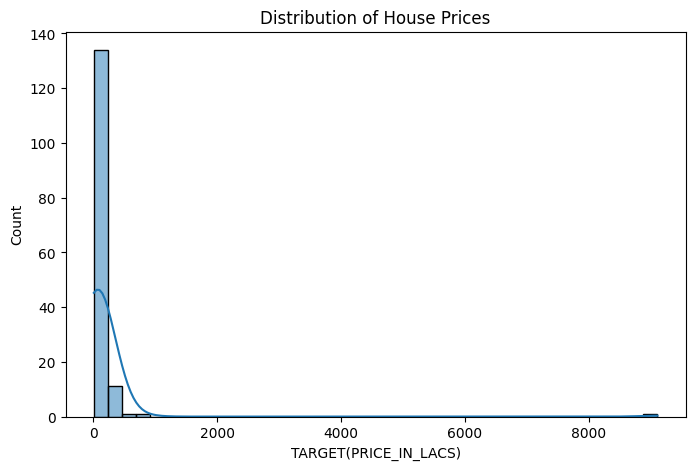

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["TARGET(PRICE_IN_LACS)"], bins=40, kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [18]:
# Feature Selection Discussion

In [19]:
# Features like Square Feet, BHK Number, Location (Address), Longitude, and Latitude are expected to have the highest influence on house prices.
# RERA status, Ready-to-Move status, and whether the property is under construction may also affect pricing. Therefore, these features are selected for model training.

In [20]:
# Handling Categorical Variables

In [21]:
categorical = ["POSTED_BY","BHK_OR_RK","ADDRESS"]

numerical = [
    "UNDER_CONSTRUCTION",
    "RERA",
    "BHK_NO.",
    "SQUARE_FT",
    "READY_TO_MOVE",
    "RESALE",
    "LONGITUDE",
    "LATITUDE"
]

In [22]:
# Correlation Heatmap

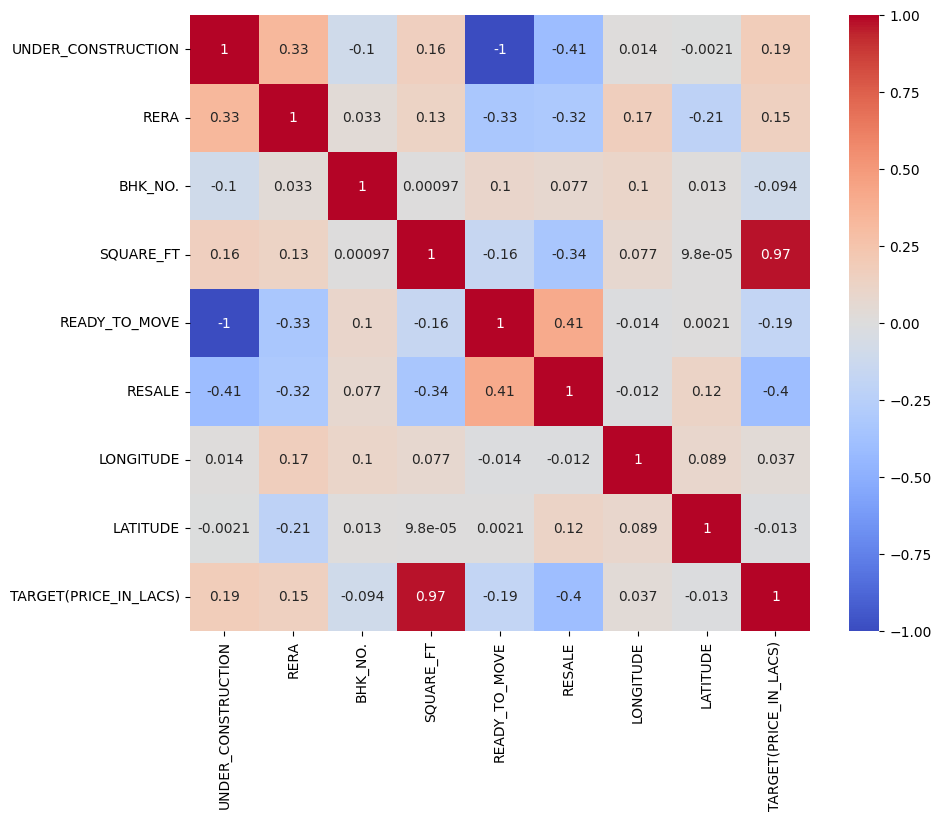

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numerical + ["TARGET(PRICE_IN_LACS)"]].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [24]:
# Training -Test Split

In [25]:
X = df.drop("TARGET(PRICE_IN_LACS)", axis=1)

y = df["TARGET(PRICE_IN_LACS)"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
# Training Linear Regression

In [27]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['POSTED_BY', 'BHK_OR_RK',
                                                   'ADDRESS'])])),
                ('regressor', LinearRegression())])

In [28]:
# Predictions

In [29]:
y_pred = model.predict(X_test)

In [30]:
# Evaluation

In [31]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE : 13619.353410942229
RMSE: 116.70198546272564
R2 Score: -1.2181133528497017


In [ ]:
# Actual vs Predicted Scatter Plot

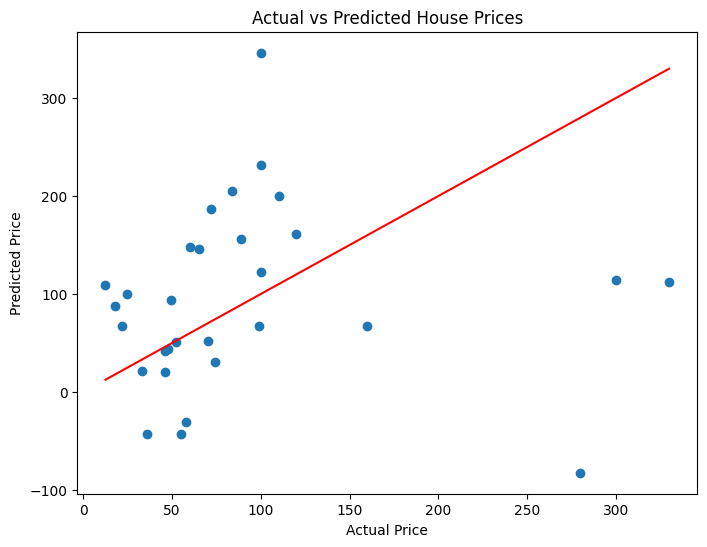

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

In [33]:
# Residual Plot

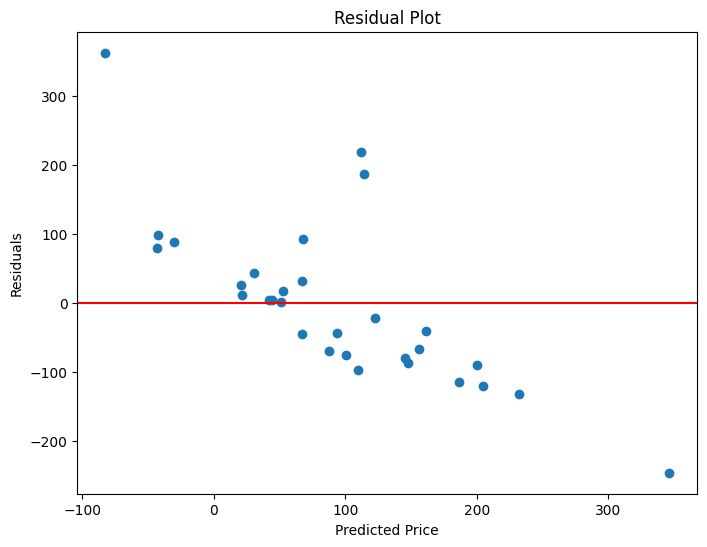

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [35]:
# Coefficient Analysis

In [36]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df.head(20)

,Feature,Coefficient
23,"cat__ADDRESS_Goregaon (East),Lalitpur",756.599457
35,"cat__ADDRESS_Kanjur Marg (East),Lalitpur",358.308905
34,"cat__ADDRESS_Kanchpada,Maharashtra",341.119242
74,"cat__ADDRESS_Sahibabad,Ghaziabad",320.459681
17,"cat__ADDRESS_DN Nagar,Maharashtra",310.559303
51,"cat__ADDRESS_Marol,Mumbai",298.364403
18,"cat__ADDRESS_Deonar,Maharashtra",223.275700
38,"cat__ADDRESS_Kharar,Mohali",198.165020
72,"cat__ADDRESS_Purseni,Lucknow",178.026127
114,"cat__ADDRESS_Wadala East,Lalitpur",168.490435


In [37]:
# Ridge Regression

In [38]:
ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: -0.8379669915180041


In [39]:
# Lasso Regression

In [40]:
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.1))
])

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: 0.09570401803700901


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 111365.25237645212, tolerance: 8193.201373762713
  model = cd_fast.sparse_enet_coordinate_descent(


In [41]:
# Conclusion
# Successfully performed Exploratory Data Analysis (EDA).
# Verified that the dataset contains no missing values.
# Encoded categorical variables using One-Hot Encoding.
# Built a Linear Regression model to predict house prices.
# Evaluated the model using MSE, RMSE, and R² Score.
# Visualized Actual vs Predicted Prices and Residual Distribution.
# Analyzed feature coefficients to understand the impact of each feature.
# Compared Linear Regression with Ridge and Lasso Regression models.